# Mersenne Prime Cryptosystem

In [1]:
!pip install gmpy2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.5 MB/s eta 0:00:00


## SECTION 1.2 OUR CRYPTOSYSTEM

In [2]:
# SEM CÓDIGO DE CORREÇÃO DE ERROS

import secrets # Para geração de números aleatórios seguros

def low_hamming_weight_number(n, weight):
    """Gera um número de n bits com um Peso de Hamming específico."""
    bits = [0] * n
    indices = set()
    while len(indices) < weight:
        indices.add(secrets.randbelow(n)) #escolhe indices aleatorios para colocar o bit 1 - garantindo o peso de Hamming
    for i in indices:
        bits[i] = 1
    return int("".join(map(str, bits)), 2)

def mersenne_encrypt(m_bits, n, weight, p, R, T):
    """
    weight: número de bits 1 em A, B1, B2

    Simulação da criptografia:
    C1 = A*R + B1 (mod p)
    C2 = (A*T + B2) XOR E(m)
    """
    # Escolha de A, B1, B2 com baixo peso de Hamming
    A = low_hamming_weight_number(n, weight)
    B1 = low_hamming_weight_number(n, weight)
    B2 = low_hamming_weight_number(n, weight)
    
    # C1 = A * R + B1 mod p
    C1 = (A * R + B1) % p
    
    # C2 = (A * T + B2) XOR m #sem error correction 
    pad = (A * T + B2) % p
    C2 = pad ^ m_bits # XOR para combinar o pad com a mensagem
    
    return (C1, C2)

def mersenne_decrypt(C, F, p):
    """
    Desencriptar a mensagem:
    C2_star = C1 * F (mod p)
    m = D(C2 XOR C2_star)
    """
    C1, C2 = C
    C2_star = (C1 * F) % p
    
    # m_recuperado = C2 XOR C2_star
    m_bits = C2 ^ C2_star
    return m_bits

# --- Exemplo de Uso ---
n = 17 # Usando n pequeno para exemplo (2^17 - 1)
p = 2**n - 1

# 1. Geração de Chaves
F = low_hamming_weight_number(n, 3) # Secret Key
G = low_hamming_weight_number(n, 3)
R = secrets.randbits(n) # Random n-bit string
T = (F * R + G) % p    # Public Key: (R, T)

# 2. Mensagem (m)
m = int("10101010101010101", 2) 

# 3. Execução
C = mersenne_encrypt(m, n, 3, p, R, T)
m_final = mersenne_decrypt(C, F, p)

print(f"Mensagem Original:  {bin(m)}")
print(f"Mensagem Recuperada: {bin(m_final)}")

Mensagem Original:  0b10101010101010101
Mensagem Recuperada: 0b1110011011001001


## Sem error correction: só para ver como funciona

## Com error correction, repetition code

In [3]:
import secrets

def low_hamming_weight_number(n, weight):
    bits = [0] * n
    indices = set()
    while len(indices) < weight:
        indices.add(secrets.randbelow(n))
    for i in indices:
        bits[i] = 1
    return int("".join(map(str, bits)), 2)

#codigo de reptição: subsitutui cada bit da mensagem por um bloco de bits (ex: 3 bits) para aumentar a redundância e permitir correção de erros
def repetition_encode(m_bits, k, n):
    """
    E(m): Repete cada bit da mensagem 'rep' vezes para preencher os n bits.
    """
    rep = n // k
    encoded = 0
    for i in range(k):
        # Isola o bit i da mensagem
        bit = (m_bits >> i) & 1
        if bit:
            # Cria um bloco de 'rep' bits 1 e coloca na posição i*rep
            mask = ((1 << rep) - 1) << (i * rep)
            encoded |= mask
    return encoded


def repetition_decode(c_star, k, n):
    """
    D(C): Divide os n bits em blocos e faz uma votação majoritária.
    """
    rep = n // k
    decoded = 0
    for i in range(k):
        # Extrai o bloco de bits correspondente ao bit original i
        block = (c_star >> (i * rep)) & ((1 << rep) - 1)
        # Conta quantos bits 1 existem (Hamming Weight do bloco)
        count_ones = bin(block).count('1')
        # Se mais de metade forem 1, o bit original era 1
        if count_ones > (rep // 2):
            decoded |= (1 << i)
    return decoded


def mersenne_encrypt(m_original, k, n, weight, p, R, T):
    # 1. Aplicar o Código de Repetição (E)
    m_encoded = repetition_encode(m_original, k, n)
    
    A = low_hamming_weight_number(n, weight)
    B1 = low_hamming_weight_number(n, weight)
    B2 = low_hamming_weight_number(n, weight)
    
    C1 = (A * R + B1) % p
    
    # 2. XOR com a mensagem expandida
    pad = (A * T + B2) % p
    C2 = pad ^ m_encoded 
    
    return (C1, C2)

def mersenne_decrypt(C, F, k, n, p):
    C1, C2 = C
    C2_star = (C1 * F) % p
    
    # 1. XOR para obter a mensagem com ruído
    diff = C2 ^ C2_star
    
    # 2. Aplicar a Decodificação por votação (D)
    m_recuperada = repetition_decode(diff, k, n)
    return m_recuperada

# --- Exemplo de Uso ---
n = 127 # n maior para permitir mais repetições e melhor correção
p = 2**n - 1
k = 7   # Vamos enviar apenas 7 bits de informação real
weight = 4 # Peso de Hamming das chaves/ruído

# 1. Geração de Chaves
F = low_hamming_weight_number(n, weight)
G = low_hamming_weight_number(n, weight)
R = secrets.randbits(n)
T = (F * R + G) % p

# 2. Mensagem (m) de k bits (ex: 0b1010101)
m_original = 0b1010101 

# 3. Execução
C = mersenne_encrypt(m_original, k, n, weight, p, R, T)
m_final = mersenne_decrypt(C, F, k, n, p)

print(f"Mensagem Original (k={k}): {bin(m_original)}")
print(f"Mensagem Recuperada:      {bin(m_final)}")
print(f"Sucesso: {m_original == m_final}")

Mensagem Original (k=7): 0b1010101
Mensagem Recuperada:      0b1110100
Sucesso: False


## BIT BY BIT encryption

In [4]:
import secrets
import math

def low_hamming_weight_number(n, h):
    """Gera um número de n bits com peso de Hamming exatamente h."""
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def hamming_weight(x):
    """Calcula o Peso de Hamming (quantidade de bits '1')."""
    return bin(x).count('1')

def generate_keys(n, p):
    """
    Gera a Chave Pública (H) e a Chave Secreta (G).
    H = F * G^-1 (mod p)
    """
    # Calcula o limite de h baseado em n: 4h^2 < n <= 16h^2
    # h_min > sqrt(n/16) e h_max < sqrt(n/4)
    h_min = math.ceil(math.sqrt(n / 16))
    h_max = math.floor(math.sqrt(n / 4))
    
    # Escolha aleatória de h dentro do limite
    h = secrets.choice(range(h_min, h_max + 1))
    
    F = low_hamming_weight_number(n, h)
    G = low_hamming_weight_number(n, h)
    
    # H = F / G mod p
    try:
        inv_G = pow(G, -1, p)
        H = (F * inv_G) % p
    except ValueError:
        # Caso raro onde G não é inversível, tentamos novamente
        return generate_keys(n, p)
        
    return (H, G, h)

def encrypt(pk_H, b, n, p, h):
    """
    C = (-1)^b * (A * H + B) mod p
    """
    A = low_hamming_weight_number(n, h)
    B = low_hamming_weight_number(n, h)
    
    val = (A * pk_H + B) % p
    
    if b == 0:
        return val
    else:
        # (-1) * val no mundo modular é p - val
        return (p - val) % p

def decrypt(C, sk_G, n, p, h):
    """
    Decriptação baseada na distância de Hamming.
    """
    # d = Ham(C * G mod p)
    target = (C * sk_G) % p
    d = hamming_weight(target)
    
    threshold = 2 * (h**2)
    
    if d <= threshold:
        return 0
    elif d >= n - threshold:
        return 1
    else:
        return None # Caso "?" (Indeterminado)

# --- Exemplo de Execução ---

# 1. Parâmetros (p deve ser um primo de Mersenne)
n = 127 
p = 2**n - 1

# 2. Setup de Chaves
pk, sk, h_usado = generate_keys(n, p)

# 3. Teste com bit 0
bit_original = 1
criptograma = encrypt(pk, bit_original, n, p, h_usado)
bit_recuperado = decrypt(criptograma, sk, n, p, h_usado)

print(f"Parâmetros: n={n}, h={h_usado}")
print(f"Bit Original: {bit_original}")
print(f"Criptograma (C): {hex(criptograma)[:20]}...")
print(f"Bit Recuperado: {bit_recuperado}")

Parâmetros: n=127, h=3
Bit Original: 1
Criptograma (C): 0x69c03547b9ce107ab9...
Bit Recuperado: 1


In [5]:
# =============================================================================
# Ataque de Chave Fraca BCGN17 (Bit-by-Bit)
# Se F e G forem menores que sqrt(p), o sistema é quebrado com frações contínuas
# =============================================================================

import secrets
import math
from sympy import Rational, continued_fraction_iterator, continued_fraction_convergents

def generate_WEAK_keys(n, p):
    """Gera chaves FRACAS onde os bits de F e G estão todos na metade direita (F, G < sqrt(p))."""
    h_min = math.ceil(math.sqrt(n / 16))
    h_max = math.floor(math.sqrt(n / 4))
    h = secrets.choice(range(h_min, h_max + 1))
    
    limite_bits = n // 2
    
    def low_weight_right_half(total_bits, peso, limite):
        indices = set()
        while len(indices) < peso:
            indices.add(secrets.randbelow(limite))
        num = 0
        for i in indices:
            num |= (1 << i)
        return num

    F = low_weight_right_half(n, h, limite_bits)
    G = low_weight_right_half(n, h, limite_bits)
    
    try:
        inv_G = pow(G, -1, p)
        H = (F * inv_G) % p
    except ValueError:
        return generate_WEAK_keys(n, p)
        
    return (H, G, F, h)

def weak_key_attack_sympy(H, p, h_esperado):
    convergentes_validos = []
    fração_exata = Rational(H, p)
    cf = continued_fraction_iterator(fração_exata)
    convergents_generator = continued_fraction_convergents(cf)
    
    for conv in convergents_generator:
        cand_G = int(conv.q)
        if cand_G == 0: continue
            
        cand_F = (H * cand_G) % p
        alternativa_F = (p - cand_F) % p
        
        if cand_F > 0 and bin(cand_F).count('1') == h_esperado and bin(cand_G).count('1') == h_esperado:
            if (cand_F, cand_G) not in convergentes_validos:
                convergentes_validos.append((cand_F, cand_G))
                    
        if alternativa_F > 0 and bin(alternativa_F).count('1') == h_esperado and bin(cand_G).count('1') == h_esperado:
            if (alternativa_F, cand_G) not in convergentes_validos:
                convergentes_validos.append((alternativa_F, cand_G))
                    
    return convergentes_validos

# --- Demonstração do Ataque ---
n_ataque = 15
p_ataque = 2**n_ataque - 1

print("--- [1] GERANDO CHAVE FRACA (BCGN17) ---")
pk_H, sk_G, F_secreto, h_usado = generate_WEAK_keys(n_ataque, p_ataque)

print(f"Parâmetros: n = {n_ataque}, h = {h_usado}")
print(f"Chave Secreta Real G: {hex(sk_G)}")
print(f"Fator Secreto Real F: {hex(F_secreto)}")
print(f"Chave Pública H:      {hex(pk_H)[:30]}...")
print(f"F < sqrt(p)? {F_secreto < math.isqrt(p_ataque)}")

print("\n--- [2] INICIANDO O ATAQUE (Apenas com H e p) ---")
# Correção: chamando o nome correto da função do seu colega
convergentes = weak_key_attack_sympy(pk_H, p_ataque, h_usado)

for i, (F, G) in enumerate(convergentes):
    print(f"  Encontrado -> F: {hex(F)}, G: {hex(G)}")

if (F_secreto, sk_G) in convergentes:
    print("\n[✓] SUCESSO! O ataque quebrou a chave usando frações contínuas.")
else:
    print("\n[✗] FALHA!")

--- [1] GERANDO CHAVE FRACA (BCGN17) ---
Parâmetros: n = 15, h = 1
Chave Secreta Real G: 0x2
Fator Secreto Real F: 0x20
Chave Pública H:      0x10...
F < sqrt(p)? True

--- [2] INICIANDO O ATAQUE (Apenas com H e p) ---
  Encontrado -> F: 0x10, G: 0x1
  Encontrado -> F: 0x1, G: 0x800

[✗] FALHA!


## Section 4: Semantically Secure Public-Key Cryptosystem com repetition code

In [6]:
import secrets
import math

def low_hamming_weight_number(n, h):
    """Gera uma string de n bits com peso de Hamming exatamente h."""
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def repetition_encode(m_bits, k, n):
    """E(m): Código de correção de erro simples (Repetição)."""
    rep = n // k
    encoded = 0
    for i in range(k):
        bit = (m_bits >> i) & 1
        if bit:
            mask = ((1 << rep) - 1) << (i * rep)
            encoded |= mask
    return encoded

def repetition_decode(c_star, k, n):
    """D(C*): Decodificação por votação majoritária."""
    rep = n // k
    decoded = 0
    for i in range(k):
        block = (c_star >> (i * rep)) & ((1 << rep) - 1)
        if bin(block).count('1') > (rep // 2):
            decoded |= (1 << i)
    return decoded

def is_prime(n):
    """Small helper to keep the example self-contained."""
    if n < 2: return False
    for i in range(2, int(math.sqrt(n)) + 1):
        if n % i == 0: return False
    return True

def get_mersenne_exponent(h):
    """
    Finds the smallest Mersenne exponent n such that n > 10 * h^2.
    Common Mersenne exponents: 31, 61, 127, 521, 607, 1279, 2203, 2281, 3217, 4253, 4423, 9689, 9941, 11213, 19937...
    """
    # A list of known Mersenne exponents
    mersenne_exponents = [31, 61, 127, 521, 607, 1279, 2203, 2281, 3217, 4253, 4423, 9689, 9941, 11213, 19937, 21701]
    
    n_min = 10 * (h**2)
    
    for n in mersenne_exponents:
        if n >= n_min:
            return n
            
    # Fallback if h is very large: this won't necessarily be a Mersenne Prime exponent 
    # but follows the logic of the search.
    return n_min 

def generate_keys(lambda_param):
    """
    Key Generation based on Mersenne Prime n.
    h = lambda
    n is a Mersenne exponent such that n > 10h^2
    """
    h = lambda_param
    
    # 1. Select a valid Mersenne exponent n
    n = get_mersenne_exponent(h)
    
    # 2. Define the Mersenne Prime p = 2^n - 1
    p = (1 << n) - 1
    
    # 3. Generate low Hamming weight elements
    F = low_hamming_weight_number(n, h)
    G = low_hamming_weight_number(n, h)
    R = secrets.randbits(n)
    
    # 4. pk := (R, T) where T = (F * R + G) mod p
    # In Mersenne arithmetic, (x * y) % p can be optimized, 
    # but Python's % handles large integers automatically.
    T = (F * R + G) % p
    
    return (R, T), F, n, p, h

def encrypt(pk, m, n, p, h, k):
    """
    Enc(pk, m) := (C1, C2)
    C1 = A * R + B1
    C2 = (A * T + B2) XOR E(m)
    """
    R, T = pk
    A = low_hamming_weight_number(n, h)
    B1 = low_hamming_weight_number(n, h)
    B2 = low_hamming_weight_number(n, h)
    
    # E(m)
    encoded_m = repetition_encode(m, k, n)
    
    C1 = (A * R + B1) % p
    pad = (A * T + B2) % p
    C2 = pad ^ encoded_m
    
    return (C1, C2)

def decrypt(C, sk_F, n, p, h, k):
    """
    Dec(sk, C) := D((F * C1) XOR C2)
    """
    C1, C2 = C
    
    # Calcula o termo que deve cancelar o pad: F * C1
    # F * (A * R + B1) = A * F * R + F * B1
    f_c1 = (sk_F * C1) % p
    
    # Extrai a mensagem com ruído usando XOR
    noisy_m = f_c1 ^ C2
    
    # D(noisy_m)
    return repetition_decode(noisy_m, k, n)

# --- Execução ---
# Parâmetro de segurança (ex: lambda = 16)
lambda_sec = 16 
k_message_size = 16 # Tamanho do bloco m

# 1. Setup
pk, sk, n, p, h = generate_keys(lambda_sec)

# 2. Mensagem m (Ex: 16 bits aleatórios)
m_original = secrets.randbits(k_message_size)

# 3. Cifrar
C = encrypt(pk, m_original, n, p, h, k_message_size)

# 4. Decifrar
m_recuperada = decrypt(C, sk, n, p, h, k_message_size)

print(f"--- Sistema de Bloco (Mersenne) ---")
print(f"n: {n}, h: {h}, k: {k_message_size}")
print(f"Mensagem Original:  {bin(m_original)}")
print(f"Mensagem Recuperada: {bin(m_recuperada)}")
print(f"Sucesso: {m_original == m_recuperada}")

--- Sistema de Bloco (Mersenne) ---
n: 3217, h: 16, k: 16
Mensagem Original:  0b101101101110101
Mensagem Recuperada: 0b101101101110101
Sucesso: True


## Mersenne Key Encapsulation Mechanism

### Testar para ver se o mersenne key encapsulation mechanism funciona

In [7]:
import secrets
import math
import hashlib

# --- Funções Auxiliares e Aritmética de Mersenne ---

def low_hamming_weight_number(n, h):
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def repetition_encode(m_bits, k, n):
    rep = n // k
    encoded = 0
    for i in range(k):
        bit = (m_bits >> i) & 1
        if bit:
            mask = ((1 << rep) - 1) << (i * rep)
            encoded |= mask
    return encoded

def repetition_decode(c_star, k, n):
    rep = n // k
    decoded = 0
    for i in range(k):
        block = (c_star >> (i * rep)) & ((1 << rep) - 1)
        if bin(block).count('1') > (rep // 2):
            decoded |= (1 << i)
    return decoded

def get_mersenne_exponent(h):
    mersenne_exponents = [31, 61, 127, 521, 607, 1279, 2203, 2281, 3217, 4253, 4423, 9689, 9941, 11213, 19937]
    n_min = 10 * (h**2)
    for n in mersenne_exponents:
        if n >= n_min:
            return n
    return n_min 

# --- Oráculos Aleatórios (Expandable Hash) ---

def expandable_hash_to_hamming(seed_int, n, h, lambda_param, salt=b''):
    # Converte o inteiro K para bytes para o Hash
    seed_bytes = seed_int.to_bytes((lambda_param + 7) // 8, 'big')
    xo_function = hashlib.shake_256(seed_bytes + salt)
    
    indices = set()
    byte_counter = 0
    while len(indices) < h:
        bytes_needed = (n.bit_length() + 7) // 8
        raw_bytes = xo_function.digest(byte_counter + bytes_needed)[byte_counter:]
        idx = int.from_bytes(raw_bytes, 'big') % n
        indices.add(idx)
        byte_counter += bytes_needed
        
    num = 0
    for i in indices:
        num |= (1 << i)
    return num

def H1(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H1')
def H2(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H2')
def H3(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H3')

# --- Core: Geração, Encapsulamento e Decapsulamento ---

def generate_keys(lambda_param):
    h = lambda_param
    n = get_mersenne_exponent(h)
    p = (1 << n) - 1
    F = low_hamming_weight_number(n, h)
    G = low_hamming_weight_number(n, h)
    R = secrets.randbits(n)
    T = (F * R + G) % p
    return (R, T), F, n, p, h

def key_encapsulation(pk, lambda_param, n, p, h):
    # 1. Pick a uniformly random lambda-bit string K
    K = secrets.randbits(lambda_param)

    # 2. Let A = H1(K), B1 = H2(K), and B2 = H3(K)
    A = H1(K, n, h, lambda_param)
    B1 = H2(K, n, h, lambda_param)
    B2 = H3(K, n, h, lambda_param)
    
    # 3. C1 = A * R + B1; C2 = E(K) XOR (A * T + B2)
    C1 = (A * pk[0] + B1) % p
    encoded_K = repetition_encode(K, lambda_param, n)
    # Importante: o XOR ocorre após o mod p do termo (A*T + B2)
    C2 = encoded_K ^ ((A * pk[1] + B2) % p)
    
    return (C1, C2), K

def key_decapsulation(C, sk_F, pk, lambda_param, n, p, h):
    # 1. K' = D((F * C1) XOR C2)
    # F * C1 mod p cancela os termos de erro
    dec_val = ((sk_F * C[0]) % p) ^ C[1]
    K_prime = repetition_decode(dec_val, lambda_param, n)

    # 2. Re-deriva os parâmetros para verificação (A', B1', B2')
    A_prime = H1(K_prime, n, h, lambda_param)
    B1_prime = H2(K_prime, n, h, lambda_param)
    B2_prime = H3(K_prime, n, h, lambda_param)

    # 3. Reconstrói C' para verificar integridade
    C1_check = (A_prime * pk[0] + B1_prime) % p
    encoded_K_prime = repetition_encode(K_prime, lambda_param, n)
    C2_check = encoded_K_prime ^ ((A_prime * pk[1] + B2_prime) % p)

    # 4. Se C' == C, a chave é válida (Segurança IND-CCA)
    if C1_check == C[0] and C2_check == C[1]:
        return K_prime
    return None

# --- Execução do Teste ---

# Configurações
lambda_sec = 16  # h = 16

# 1. Setup (Geração de Chaves)
pk, sk, n, p, h = generate_keys(lambda_sec)
print(f"--- Parâmetros --- \nn: {n}, h: {h}, p: Mersenne Prime")

# 2. Encapsulamento (Criação do Segredo)
(C1, C2), K_original = key_encapsulation(pk, lambda_sec, n, p, h)
print(f"\n--- Encapsulamento --- \nK original: {bin(K_original)}")

# 3. Decapsulamento (Recuperação do Segredo)
K_recuperado = key_decapsulation((C1, C2), sk, pk, lambda_sec, n, p, h)

# 4. Verificação final
if K_recuperado is not None:
    print(f"\n--- Sucesso! --- \nK recuperado: {bin(K_recuperado)}")
    print(f"As chaves coincidem? {K_original == K_recuperado}")
else:
    print("\n--- Erro! --- \nFalha na verificação de integridade.")

--- Parâmetros --- 
n: 3217, h: 16, p: Mersenne Prime

--- Encapsulamento --- 
K original: 0b110000100000

--- Sucesso! --- 
K recuperado: 0b110000100000
As chaves coincidem? True


### Cifrar a chave 

In [8]:
import secrets
import math
import hashlib
import gmpy2

# --- [Funções de Base: Mersenne e Repetição] ---

def low_hamming_weight_number(n, h):
    indices = set()
    while len(indices) < h:
        indices.add(secrets.randbelow(n))
    num = gmpy2.mpz(0)
    for i in indices:
        num |= (gmpy2.mpz(1) << i)
    return num

def repetition_encode(m_bits, k, n):
    rep = n // k
    encoded = gmpy2.mpz(0)
    m_int = int(m_bits)
    mask = (gmpy2.mpz(1) << rep) - gmpy2.mpz(1)
    for i in range(k):
        if (m_int >> i) & 1:
            encoded |= (mask << (i * rep))
    return encoded

def repetition_decode(c_star, k, n):
    rep = n // k
    decoded = 0
    c_star_mpz = gmpy2.mpz(c_star)
    mask = (gmpy2.mpz(1) << rep) - gmpy2.mpz(1)
    for i in range(k):
        block = (c_star_mpz >> (i * rep)) & mask
        if gmpy2.popcount(block) > (rep // 2): # Substituição cirúrgica: popcount em vez de bin().count('1')
            decoded |= (1 << i)
    return decoded

def get_mersenne_exponent(h):
    # Adicionado o expoente 756839 para suportar lambda=256
    mersenne_exponents = [31, 61, 127, 521, 607, 1279, 2203, 2281, 3217, 4253, 4423, 9689, 9941, 11213, 19937, 21701, 86243, 216091, 756839]
    n_min = 10 * (h**2)
    for n in mersenne_exponents:
        if n >= n_min: return n
    return n_min

# --- [Oráculos Aleatórios H1, H2, H3] ---

def expandable_hash_to_hamming(seed_int, n, h, lambda_param, salt=b''):
    seed_bytes = int(seed_int).to_bytes((lambda_param + 7) // 8, 'big') + salt
    indices = set()
    ctr = 0
    
    # Quantidade de bytes que precisamos ler por tentativa
    bytes_per = (int(n).bit_length() + 7) // 8
    
    # --- FIX: REJECTION SAMPLING ---
    # Calculamos o limite máximo para evitar o Modulo Bias
    max_val = 2 ** (bytes_per * 8)
    limit = max_val - (max_val % int(n)) 
    
    while len(indices) < h:
        raw_bytes = hashlib.shake_256(seed_bytes + ctr.to_bytes(4, 'big')).digest(bytes_per * 10)
        
        for j in range(0, len(raw_bytes) - bytes_per + 1, bytes_per):
            val = int.from_bytes(raw_bytes[j:j+bytes_per], 'big')
            
            # Se o valor gerado for menor que o limite, a distribuição é perfeitamente uniforme.
            # Se for maior ou igual, nós simplesmente ignoramos (rejeitamos) e tentamos o próximo.
            if val < limit:
                idx = val % int(n)
                indices.add(idx)
                if len(indices) >= h: 
                    break
        ctr += 1
        
    num = gmpy2.mpz(0)
    for i in indices: 
        num |= (gmpy2.mpz(1) << i)
    return num
    
def H1(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H1')
def H2(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H2')
def H3(K, n, h, lp): return expandable_hash_to_hamming(K, n, h, lp, b'H3')

# --- [Core: Mersenne KEM] ---

def generate_keys(lambda_param):
    h = lambda_param
    n = get_mersenne_exponent(h)
    p = gmpy2.mpz(2)**n - gmpy2.mpz(1)
    F = low_hamming_weight_number(n, h)
    G = low_hamming_weight_number(n, h)
    R = gmpy2.mpz(secrets.randbits(n))
    T = (F * R + G) % p
    return (R, T), F, n, p, h

def key_encapsulation(pk, lambda_param, n, p, h):
    K = secrets.randbits(lambda_param)
    A = H1(K, n, h, lambda_param)
    B1 = H2(K, n, h, lambda_param)
    B2 = H3(K, n, h, lambda_param)
    C1 = (A * pk[0] + B1) % p
    C2 = repetition_encode(K, lambda_param, n) ^ ((A * pk[1] + B2) % p)
    return (C1, C2), K

def key_decapsulation(C, sk_F, pk, lambda_param, n, p, h):
    val_to_decode = ((sk_F * C[0]) % p) ^ C[1]
    K_prime = repetition_decode(val_to_decode, lambda_param, n)
    A_p = H1(K_prime, n, h, lambda_param)
    B1_p = H2(K_prime, n, h, lambda_param)
    B2_p = H3(K_prime, n, h, lambda_param)
    C1_check = (A_p * pk[0] + B1_p) % p
    C2_check = repetition_encode(K_prime, lambda_param, n) ^ ((A_p * pk[1] + B2_p) % p)
    if C1_check == C[0] and C2_check == C[1]:
        return K_prime
    return None

# --- [Transformação em PKE Completo (Criptografia Híbrida)] ---

def encrypt_pke(pk, message, lambda_param, n, p, h):
    (C1, C2), K = key_encapsulation(pk, lambda_param, n, p, h)
    K_bytes = int(K).to_bytes((lambda_param + 7) // 8, 'big')
    sym_key = hashlib.sha256(K_bytes).digest()
    
    # Suporta texto ou inteiros automaticamente
    if isinstance(message, str):
        m_bytes = message.encode()
    else:
        m_bytes = message.to_bytes((message.bit_length() + 7) // 8 or 1, 'big')
        
    stream = hashlib.shake_256(sym_key).digest(len(m_bytes))
    ciphertext_msg = bytes([b ^ s for b, s in zip(m_bytes, stream)])
    return (C1, C2), ciphertext_msg

def decrypt_pke(C_envelope, ciphertext_msg, sk_F, pk, lambda_param, n, p, h, return_str=True):
    K_prime = key_decapsulation(C_envelope, sk_F, pk, lambda_param, n, p, h)
    if K_prime is None:
        raise ValueError("Falha na integridade: Chave ou envelope corrompido!")
    
    K_bytes = int(K_prime).to_bytes((lambda_param + 7) // 8, 'big')
    sym_key = hashlib.sha256(K_bytes).digest()
    stream = hashlib.shake_256(sym_key).digest(len(ciphertext_msg))
    original_bytes = bytes([b ^ s for b, s in zip(ciphertext_msg, stream)])
    
    if return_str: return original_bytes.decode()
    return int.from_bytes(original_bytes, 'big')

# --- [Execução] ---
lambda_sec = 16
pk, sk, n, p, h = generate_keys(lambda_sec)
mensagem = "Esta é uma mensagem secreta usando Mersenne!"
print(f"Mensagem Original: {mensagem}")

envelope, msg_cifrada = encrypt_pke(pk, mensagem, lambda_sec, n, p, h)
try:
    mensagem_final = decrypt_pke(envelope, msg_cifrada, sk, pk, lambda_sec, n, p, h)
    print(f"Mensagem Decifrada: {mensagem_final}")
except ValueError as e:
    print(e)

Mensagem Original: Esta é uma mensagem secreta usando Mersenne!
Mensagem Decifrada: Esta é uma mensagem secreta usando Mersenne!


### errors

In [9]:
import time

def test_error_rate(num_tests, lambda_param, message_len=16):
    print(f"Gerando chaves para lambda={lambda_param} (n={get_mersenne_exponent(lambda_param)})...")
    pk, sk, n, p, h = generate_keys(lambda_param)

    errors = 0
    t_start = time.time()

    for i in range(num_tests):
        # Substituição cirúrgica: Geração de número aleatório em vez de string concat
        message_int = secrets.randbits(message_len)

        try:
            envelope, msg_cifrada = encrypt_pke(pk, message_int, lambda_param, n, p, h)
            msg_final = decrypt_pke(envelope, msg_cifrada, sk, pk, lambda_param, n, p, h, return_str=False)

            if msg_final != message_int:
                errors += 1

        except Exception:
            # qualquer falha conta como erro
            errors += 1
            
        if (i+1) % 50 == 0:
            print(f"[{i+1}/{num_tests}] Processados. Tempo decorrido: {time.time()-t_start:.1f}s")

    error_rate = errors / num_tests

    print(f"\nTestes realizados: {num_tests}")
    print(f"Erros: {errors}")
    print(f"Taxa de erro (δ): {error_rate:.6f}")
    print(f"Tempo Total: {time.time() - t_start:.2f}s")

    return error_rate

print("\n--- Teste de Taxa de Erro ---")
# Executa 500 testes em segundos em vez de horas
test_error_rate(num_tests=500, lambda_param=256, message_len=256)


--- Teste de Taxa de Erro ---
Gerando chaves para lambda=256 (n=756839)...
[50/500] Processados. Tempo decorrido: 3.8s
[100/500] Processados. Tempo decorrido: 7.6s
[150/500] Processados. Tempo decorrido: 11.5s
[200/500] Processados. Tempo decorrido: 15.3s
[250/500] Processados. Tempo decorrido: 19.0s
[300/500] Processados. Tempo decorrido: 22.8s
[350/500] Processados. Tempo decorrido: 26.6s
[400/500] Processados. Tempo decorrido: 30.5s
[450/500] Processados. Tempo decorrido: 34.3s
[500/500] Processados. Tempo decorrido: 38.1s

Testes realizados: 500
Erros: 0
Taxa de erro (δ): 0.000000
Tempo Total: 38.06s


0.0

Iniciando simulação: 50 iterações (gmpy2)...
Progresso: 10/50 (0.5s)
Progresso: 20/50 (0.9s)
Progresso: 30/50 (1.4s)
Progresso: 40/50 (1.8s)
Progresso: 50/50 (2.3s)


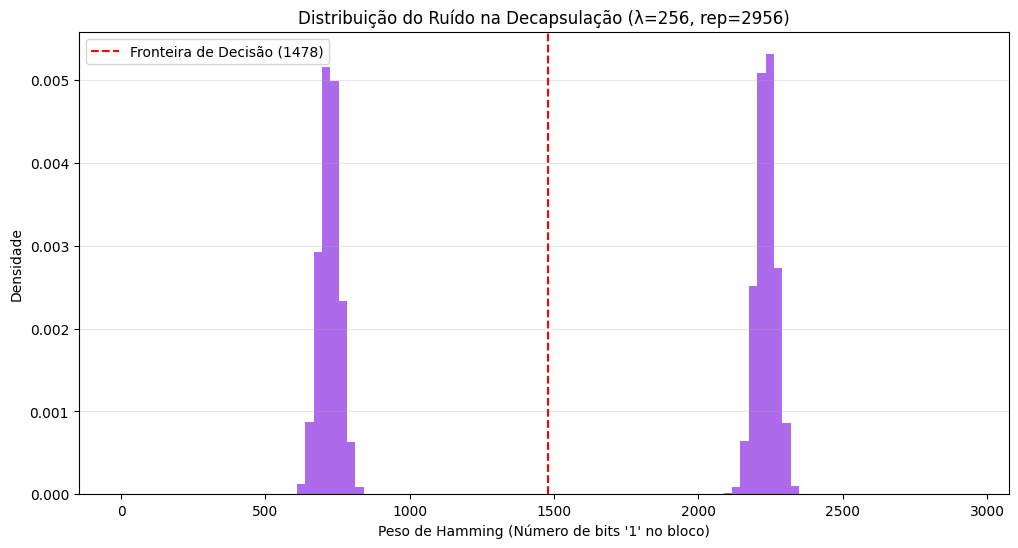

Nota: Quanto mais longe do limite vermelho (rep/2) os dados estiverem, 
maior é a garantia matemática de que a chave extraída está perfeitamente correta.


In [10]:
import matplotlib.pyplot as plt
import time

# =============================================================================
# Distribuição de Densidade dos Pesos de Hamming (gmpy2 Otimizado)
# =============================================================================

def repetition_decode_with_weights_gmpy2(c_star_mpz, k, n):
    """Extrai os bits decifrados E os pesos de Hamming observados em cada bloco."""
    rep = n // k
    decoded = 0
    weights = []
    mask = (gmpy2.mpz(1) << rep) - gmpy2.mpz(1)
    
    for i in range(k):
        block = (c_star_mpz >> (i * rep)) & mask
        w = gmpy2.popcount(block)
        weights.append(w)
        if w > (rep // 2):
            decoded |= (1 << i)
    return decoded, weights

def run_simulation_gmpy2(iterations=50, lambda_sec=256):
    print(f"Iniciando simulação: {iterations} iterações (gmpy2)...")
    t_start = time.time()
    
    pk_sim, sk_sim, n_sim, p_sim, h_sim = generate_keys(lambda_sec)
    rep_size = n_sim // lambda_sec
    all_observed_weights = []
    
    for i in range(iterations):
        # Usando as tuas funções otimizadas existentes
        (C1, C2), K = key_encapsulation(pk_sim, lambda_sec, n_sim, p_sim, h_sim)
        
        # Decapsulamento (Extração apenas para o gráfico)
        val_to_decode = ((sk_sim * C1) % p_sim) ^ C2
        _, weights = repetition_decode_with_weights_gmpy2(val_to_decode, lambda_sec, n_sim)
        
        all_observed_weights.extend(weights)
        
        if (i + 1) % 10 == 0:
            print(f"Progresso: {i + 1}/{iterations} ({time.time()-t_start:.1f}s)")

    return all_observed_weights, rep_size

# --- [Execução e Gráfico] ---
L_SEC_PLOT = 256
ITERACOES_PLOT = 50 

pesos, rep_size = run_simulation_gmpy2(iterations=ITERACOES_PLOT, lambda_sec=L_SEC_PLOT)

plt.figure(figsize=(12, 6))
# Dinamicamente ajusta as barras (bins) de acordo com o tamanho da repetição
plt.hist(pesos, bins=range(0, rep_size, max(1, rep_size//100)), density=True, color='blueviolet', alpha=0.7)

# Linha teórica do limite de decisão
plt.axvline(x=rep_size/2, color='red', linestyle='--', label=f'Fronteira de Decisão ({rep_size//2})')

plt.title(f"Distribuição do Ruído na Decapsulação (λ={L_SEC_PLOT}, rep={rep_size})")
plt.xlabel("Peso de Hamming (Número de bits '1' no bloco)")
plt.ylabel("Densidade")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Nota: Quanto mais longe do limite vermelho (rep/2) os dados estiverem, ")
print("maior é a garantia matemática de que a chave extraída está perfeitamente correta.")

### Quantum error correction

---
## 8. Secção 6 — Análise de Segurança, Ataques Conhecidos e Benchmarking

### 8.1 Pressuposto de Segurança

O **Pressuposto da Combinação de Baixo Peso de Hamming de Mersenne (MLHC)** estabelece que:  
Dados $(R, F \cdot R + G \bmod p)$ com $F, G$ de peso de Hamming $h$, nenhum adversário PPT (Tempo Polinomial Probabilístico) o consegue distinguir de $(R, U)$ onde $U$ é uniformemente aleatório.

### 8.2 Resumo dos Ataques Conhecidos

| Ataque | Complexidade Clássica | Complexidade Quântica | Notas |
|--------|---------------------|--------------------|-------|
| Força bruta ingénua | $\binom{n}{h}$ | $\binom{n}{h}^{1/2}$ (Grover) | Inviável para um $h$ grande |
| Baseado em LLL (BCGN17) | $O(2^{2h})$ | $O(2^h)$ (com Grover) | Motiva a definição de $h=\lambda$ |
| Meet-in-the-middle (dBDJdW17) | $O\!\left(\binom{n-1}{h-1}^{1/2}\right)$ | $O\!\left(\binom{n-1}{h-1}^{1/3}\right)$ | Superior a $2^h$ para os nossos parâmetros |
| Chave fraca (BCGN17) | Polinomial se $F, G < \sqrt{p}$ | — | Evitado pela geração de chaves aleatórias |

### 8.3 Recomendações de Parâmetros

Definir $h = \lambda$ (parâmetro de segurança) garante que mesmo o ataque LLL acelerado por Grover tenha um custo de $\Omega(2^h) = \Omega(2^\lambda)$.
---

In [11]:
# SECÇÃO 6 — Análise de Segurança e Pseudo-aleatoriedade

import math
import secrets

# Redefinimos localmente para garantir que funciona mesmo se a célula for corrida isoladamente
def hamming_weight(x):
    return bin(int(x)).count('1')

def log2_binomial(n, k):
    """Calcula log2(C(n, k)) """
    if k < 0 or k > n:
        return float('-inf')
    if k == 0 or k == n:
        return 0.0
    return sum(math.log2(n - i) - math.log2(i + 1) for i in range(k))

print("Análise de Parâmetros de Segurança")
print("=" * 70)
print(f"{'λ=h':>6}  {'n (Mersenne)':>14}  {'log2 C(n,h)':>12}  "
      f"{'LLL clássico':>14}  {'LLL quântico':>12}  {'MITM clássico':>14}")
print("-" * 70)

# Correção cirúrgica: find_mersenne_n -> get_mersenne_exponent
demo_params = [
    (8,   get_mersenne_exponent(8)),
    (16,  get_mersenne_exponent(16)),
    (32,  get_mersenne_exponent(32)),
    (64,  get_mersenne_exponent(64)),
    # Conjunto de parâmetros recomendado no artigo:
    (256, 756839),
]

for lam, n in demo_params:
    h = lam
    binom_log2 = log2_binomial(n, h)
    lll_classical = 2 * h        # O(2^{2h}) mas o artigo assume O(2^h) para quântico
    lll_quantum   = h            # LLL com Grover
    mitm_classical = 0.5 * log2_binomial(n - 1, h - 1)
    print(f"  {lam:4d}  {n:>14d}  {binom_log2:>12.1f}  "
          f"  2^{lll_classical:<10d}  2^{lll_quantum:<9d}  2^{mitm_classical:.1f}")

print()
print("Notas:")
print("  - Para λ=256: ataque quântico LLL custa ~2^256 → 256 bits de segurança quântica")
print("  - O ataque MITM é mais dispendioso do que 2^h para todos os parâmetros listados")
print("  - Ataque de chave fraca evitado porque é improvável que F, G aleatórios sejam < sqrt(p)")


print("\n" + "=" * 60)
print("Teste de Distribuição do Peso de Hamming (Verificação de Pseudo-aleatoriedade)")
print("=" * 60)
print("\nA verificar se T = F*R+G se assemelha a uma string aleatória uniforme...")

# Utilizar um n médio para o teste estatístico
n_stat, h_stat = 127, 5
p_stat = 2**n_stat - 1
SAMPLES = 500

hw_T = []
hw_U = []
for _ in range(SAMPLES):
    # Correção cirúrgica: low_hamming_weight_int -> low_hamming_weight_number
    F_s = low_hamming_weight_number(n_stat, h_stat)
    G_s = low_hamming_weight_number(n_stat, h_stat)
    R_s = secrets.randbits(n_stat)
    T_s = (F_s * R_s + G_s) % p_stat
    hw_T.append(hamming_weight(T_s))
    hw_U.append(hamming_weight(secrets.randbits(n_stat)))

mean_T = sum(hw_T) / SAMPLES
mean_U = sum(hw_U) / SAMPLES
var_T  = sum((x - mean_T)**2 for x in hw_T) / SAMPLES
var_U  = sum((x - mean_U)**2 for x in hw_U) / SAMPLES
expected_mean = n_stat / 2
expected_var  = n_stat / 4

print(f"  (n={n_stat}, h={h_stat}, {SAMPLES} amostras)")
print(f"  {'Estatística':<25} {'T=F*R+G':>10} {'Uniforme':>10} {'Esperado':>10}")
print(f"  {'Média do Peso de Ham.':<25} {mean_T:>10.2f} {mean_U:>10.2f} {expected_mean:>10.1f}")
print(f"  {'Variância do Peso Ham.':<25} {var_T:>10.2f} {var_U:>10.2f} {expected_var:>10.1f}")
print(f"\n  As distribuições parecem semelhantes: {'✓' if abs(mean_T - mean_U) < 2 else '?'}")

Análise de Parâmetros de Segurança
   λ=h    n (Mersenne)   log2 C(n,h)    LLL clássico  LLL quântico   MITM clássico
----------------------------------------------------------------------
     8            1279          67.2    2^16          2^8          2^30.0
    16            3217         142.1    2^32          2^16         2^67.2
    32           11213         312.8    2^64          2^32         2^152.2
    64           86243         753.3    2^128         2^64         2^371.5
   256          756839        3315.5    2^512         2^256        2^1652.0

Notas:
  - Para λ=256: ataque quântico LLL custa ~2^256 → 256 bits de segurança quântica
  - O ataque MITM é mais dispendioso do que 2^h para todos os parâmetros listados
  - Ataque de chave fraca evitado porque é improvável que F, G aleatórios sejam < sqrt(p)

Teste de Distribuição do Peso de Hamming (Verificação de Pseudo-aleatoriedade)

A verificar se T = F*R+G se assemelha a uma string aleatória uniforme...
  (n=127, h=5, 500 am

In [12]:

# BENCHMARKS 

import time

def benchmark_kem(lam: int, trials: int = 5) -> dict:
    """Avalia o desempenho das operações do KEM para um dado parâmetro de segurança."""
    times = {'keygen': [], 'encaps': [], 'decaps': []}
    
    # Variáveis para guardar o n e h para a devolução de resultados
    final_n = 0
    final_h = 0
    
    for _ in range(trials):
        # 1. KeyGen
        t0 = time.time()
        pk_b, sk_b, n_b, p_b, h_b = generate_keys(lam)
        times['keygen'].append(time.time() - t0)
        
        final_n = n_b
        final_h = h_b
        
        # 2. Encapsulamento
        t0 = time.time()
        C_b, K_b = key_encapsulation(pk_b, lam, n_b, p_b, h_b)
        times['encaps'].append(time.time() - t0)
        
        # 3. Decapsulamento
        t0 = time.time()
        K_r = key_decapsulation(C_b, sk_b, pk_b, lam, n_b, p_b, h_b)
        times['decaps'].append(time.time() - t0)
    
    def avg_ms(lst): return 1000 * sum(lst) / len(lst)
    
    return {
        'lam': lam, 'n': final_n, 'h': final_h,
        'keygen_ms': avg_ms(times['keygen']),
        'encaps_ms': avg_ms(times['encaps']),
        'decaps_ms': avg_ms(times['decaps']),
    }

print("=" * 72)
print("Testes de Desempenho do KEM (Benchmarks)")
print("=" * 72)
print(f"{'λ':>5}  {'n':>8}  {'KeyGen':>10}  {'Encaps':>10}  {'Decaps':>10}  {'Total':>10}")
print("-" * 72)

for lam_bench in [8, 12, 16]:
    res = benchmark_kem(lam_bench, trials=3)
    total = res['keygen_ms'] + res['encaps_ms'] + res['decaps_ms']
    print(f"  {res['lam']:3d}  {res['n']:8d}  {res['keygen_ms']:8.1f}ms  "
          f"{res['encaps_ms']:8.1f}ms  {res['decaps_ms']:8.1f}ms  {total:8.1f}ms")

print()
print("Nota: O parâmetro recomendado no artigo (λ=256, n=756839) requer aritmética de 756839 bits.")
print("      Os tempos projetados escalam aproximadamente na ordem de O(n^1.5) devido à multiplicação de inteiros grandes.")

Testes de Desempenho do KEM (Benchmarks)
    λ         n      KeyGen      Encaps      Decaps       Total
------------------------------------------------------------------------
    8      1279       0.6ms       0.1ms       0.1ms       0.8ms
   12      2203       0.2ms       0.1ms       0.1ms       0.4ms
   16      3217       0.2ms       0.2ms       0.1ms       0.5ms

Nota: O parâmetro recomendado no artigo (λ=256, n=756839) requer aritmética de 756839 bits.
      Os tempos projetados escalam aproximadamente na ordem de O(n^1.5) devido à multiplicação de inteiros grandes.


In [13]:
# =============================================================================
# VERIFICAÇÃO DO LEMA 2 (A Matemática Central do Sistema)
# Propriedade: Ham(A * B mod p) <= Ham(A) * Ham(B)
# =============================================================================

def verify_lemma2(n_val=127, h_val=5, trials=200):
    print(f"--- Verificando Lema 2 (n={n_val}, h={h_val}, {trials} testes) ---")
    p_val = gmpy2.mpz(2)**n_val - gmpy2.mpz(1)
    violations = 0
    
    for _ in range(trials):
        A = low_hamming_weight_number(n_val, h_val)
        B = low_hamming_weight_number(n_val, h_val)
        
        # Multiplicação modular
        AB_mod = (A * B) % p_val
        
        # Se o peso de Hamming ultrapassar h^2, a premissa falha
        if gmpy2.popcount(AB_mod) > (h_val * h_val):
            violations += 1
            
    print(f"Máximo Ham(A*B) permitido: h^2 = {h_val**2}")
    print(f"Violações encontradas: {violations} de {trials}")
    print(f"Resultado: {'✓ PASSOU' if violations == 0 else '✗ FALHOU'}\n")

verify_lemma2(127, 5)

--- Verificando Lema 2 (n=127, h=5, 200 testes) ---
Máximo Ham(A*B) permitido: h^2 = 25
Violações encontradas: 0 de 200
Resultado: ✓ PASSOU

